A typical neural network training involves:

```
Neural Network Training
│
├── Data
│   ├── Dataset Preparation
│   └── DataLoader
│
├── Model Initialization
│
└── Model Training
    ├── Forward Pass
    ├── Loss Calculation
    ├── Backpropagation
    └── Weight Update

```

<img src=https://learnopencv.com/wp-content/uploads/2024/08/c2-Module01-training-neural-networks-02.png height=500>

# Dataset Preparation

Before starting the training, it's essential to prepare the dataset properly. The quality of the data directly impacts the model's performance, following the GIGO principle—**Garbage In, Garbage Out**. High-quality, well-curated data ensures that the model can learn meaningful patterns.

[Torchvision datasets](https://pytorch.org/vision/stable/datasets.html#datasets) has a set of well structured and readily usable datasets to spin up our training instantly.
For eg:
- MNIST & FashionMNIST
- CIFAR10
- ImageNet
- Caltech101 etc.,



```python
from torchvision import datasets, transforms

# Download and load the MNIST dataset
mnist_data = datasets.MNIST(
    root=".",         # Directory where the dataset will be stored
    download=True,    # Download the dataset if it's not already available
    transform=transforms.Compose([
        transforms.ToTensor(),              # Convert image to tensor
        transforms.Normalize((0.5,), (0.5,)) # Normalize with mean and std (for grayscale)
    ])
)

```

Additionally, datasets from Kaggle competitions and institutional data are other sources of quality datasets.

In [18]:
from torchvision import datasets, transforms

# Download and load the MNIST dataset
mnist_data = datasets.MNIST(
    root=".",         # Directory where the dataset will be stored
    download=True,    # Download the dataset if it's not already available
    transform=transforms.Compose([
        transforms.ToTensor(),              # Convert image to tensor
        transforms.Normalize((0.5,), (0.5,)) # Normalize with mean and std (for grayscale)
    ])
)


## DataLoaders

Once the dataset is prepared, the next step is to load the data in batches using a [torch.utils.DataLoader](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html#datasets-dataloaders). The DataLoader is a PyTorch utility that efficiently loads data in mini-batches, shuffles the data, and handles other aspects like parallel data loading. This is crucial for training as it ensures the model can process the data into manageable chunks and in a randomized order, which helps in overfitting by reducing the risk of the model learning any sequence patterns in the dataset.

```python
from torch.utils.data import DataLoader

# Initialize DataLoader
batch_size = 64
train_loader = DataLoader(mnist_data, batch_size=batch_size, shuffle=True)

# Now 'train_loader' can be used to iterate through the data in mini-batches
for batch in train_loader:
    inputs, labels = batch

```

In [19]:
from torch.utils.data import DataLoader

# Initialize DataLoader
batch_size = 64
train_loader = DataLoader(mnist_data, batch_size=batch_size, shuffle=True)

# Now 'train_loader' can be used to iterate through the data in mini-batches
for batch in train_loader:
    inputs, labels = batch


# Model Initialization

Next, we will move to model preparation. [Torchvision](https://pytorch.org/vision/stable/models.html#models-and-pre-trained-weights), [HuggingFace](https://huggingface.co/models?other=computer-vision) and [PyTorchHub](https://pytorch.org/hub/) provides a range of pre-trained model for various computer vision tasks.

These pre-trained models are trained on larger datasets with millions of image samples and classes and can be finetuned for specific datasets, saving computational resources and achieves excellent accuracy.


```python
import torchvision.models as models

# Load a pre-trained ResNet model
model = models.resnet18(pretrained=True)

# Modify the final layer to match the number of classes in training dataset
model.fc = nn.Linear(model.fc.in_features, num_classes)

# (OR)

#PyTorchHub
model = torch.hub.load('datvuthanh/hybridnets', 'hybridnets', pretrained=True)
```

In [20]:
import torch
import torch.nn as nn
import torchvision.models as models


# Load a pre-trained ResNet model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
num_classes = 10
# Modify the final layer to match the number of classes in training dataset
model.fc = nn.Linear(model.fc.in_features, num_classes)

# (OR)

#PyTorchHub
#model = torch.hub.load('datvuthanh/hybridnets', 'hybridnets', pretrained=True)


# Model Training

Training a neural network involves several steps that are repeated over multiple steps and epochs. During each epoch, the model process the dataset in batches which helps to manage the computational overhead, especially for large datasets.

Key Steps in Training:

- Forward Pass
- Loss Calculation
- Backpropagation
- Weight Updates


Optimizers adjust the model weights during training based on gradients computed in backpropagation. Here's how we define an optimizer.

```python
import torch.optim as optim

# Initialize the optimizer (e.g., SGD, Adam)
optimizer = optim.SGD(model.parameters(), lr=0.01)
```

In [21]:
import torch.optim as optim

# Initialize the optimizer (e.g., SGD, Adam)
optimizer = optim.SGD(model.parameters(), lr=0.01)


## Forward Pass

During training, over each training step the batch of input images is forward pass through the network layers, to get predictions over entire batch.

```python
for images, targets in train_loader:

    # Forward pass
    outputs = model(images) # Model prediction
```


In [22]:
for images, targets in train_loader:

    # Forward pass
    outputs = model(images) # Model prediction


## Loss Calculation

The loss function measures the difference between the predicted outputs and the actual targets or ground truth. This helps to guide the network to improve by minimizing loss.

```python
import torch.nn.functional as F

# Calculate loss (CrossEntropyLoss for classification)
loss = F.cross_entropy(outputs, target)
```



In [23]:
import torch.nn.functional as F

# Calculate loss (CrossEntropyLoss for classification)
loss = F.cross_entropy(outputs, targets)


## Backpropagation

It is the process of computing the gradient of the loss function with respect to each of the model's trainable parameters (`requires_grad = True`). This is done by propagating the loss backward through the network.

```python
loss.backward()  # Gradient computation
```

In [24]:
loss.backward()  # Gradient computation

## Weight Update

Finally the optimizer updates the model's weight for that each batch based on computed gradients during backpropagation.


**The Weight Update Formula is:**


$$ \mathbf{w}_{\text{new}} = \mathbf{w} - \eta \nabla L(\mathbf{w}) $$



After the weight update, the gradients are are set to zero to preprare for weight updates of next step.

```python
# Update weights
optimizer.step()

# Zero the gradients after updating
optimizer.zero_grad()
```

In [25]:
# Update weights
optimizer.step()

# Zero the gradients after updating
optimizer.zero_grad()

In [27]:
# Print the model architecture
print(model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Starting training loop...
Epoch [1/5], Loss: 0.2126
Epoch [2/5], Loss: 0.0623
Epoch [3/5], Loss: 0.0392
Epoch [4/5], Loss: 0.0289
Epoch [5/5], Loss: 0.0195
Training complete!


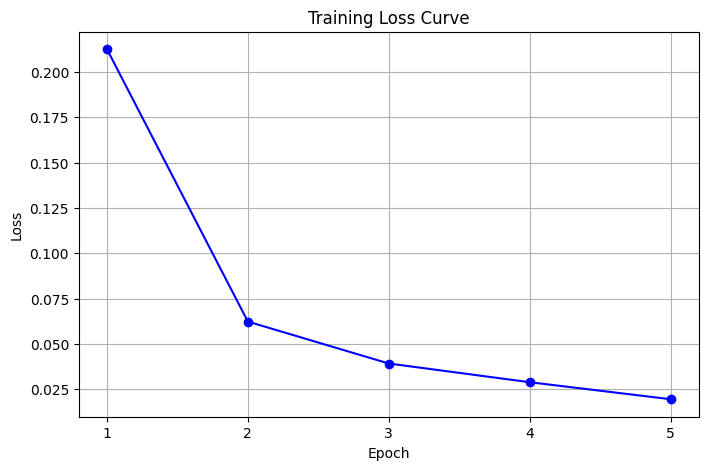

In [28]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch

# Move model to GPU to speed up training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Set up variables for 5 epochs
num_epochs = 5
epoch_losses = []

# Put model in training mode
model.train()

print("Starting training loop...")

# The actual training loop for Screenshot 2
for epoch in range(num_epochs):
    running_loss = 0.0

    for images, targets in train_loader:
        # Move data to GPU
        images, targets = images.to(device), targets.to(device)

        # 1. Zero gradients
        optimizer.zero_grad()

        # 2. Forward pass
        outputs = model(images)

        # 3. Calculate loss
        loss = F.cross_entropy(outputs, targets)

        # 4. Backward pass (Backpropagation)
        loss.backward()

        # 5. Update weights
        optimizer.step()

        running_loss += loss.item()

    # Calculate average loss for this epoch and save it
    avg_loss = running_loss / len(train_loader)
    epoch_losses.append(avg_loss)

    # This print statement provides the output for Screenshot 2
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

print("Training complete!")

# Plot the loss curve for Screenshot 3
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs+1), epoch_losses, marker='o', linestyle='-', color='b')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(1, num_epochs+1))
plt.grid(True)
plt.show() # This displays the plot

In [26]:
print("Student Name: GIDEON APPIAH")
print("Student ID:   G00457858")
print("Lab:          02 — Training Neural Networks — An Overview")

Student Name: GIDEON APPIAH
Student ID:   G00457858
Lab:          02 — Training Neural Networks — An Overview
